In [294]:
import pandas as pd
import numpy as np
from skmultilearn.model_selection import IterativeStratification
from tqdm.auto import tqdm

In [121]:
manifest = pd.read_parquet(r"../0_DataValidation/manifest.parquet")
manifest["sum_n_persons"] = manifest["n_persons"].apply(sum)

In [122]:
manifest

,country,buildingType,surrounding,buildingAgeBin,a_ref,n_apartments,year_type,future,climateRegion,n_persons,...,capControl,occControl,comfortT_lb,comfortT_ub,cores,useCache,building_id,run_id,seed,sum_n_persons
0,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,"[1, 2, 1, 4, 1, 1, 1, 5, 3, 2, 3, 3, 2, 1]",...,True,False,21.0,24.0,1,False,0,run_000000,1000000,30
1,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,"[1, 2, 1, 4, 1, 1, 1, 5, 3, 2, 3, 3, 2, 1]",...,True,False,21.0,24.0,1,False,0,run_000001,1000001,30
2,DE,AB,Terraced,DE.02,1234.5,14,cold,False,4,"[1, 2, 1, 4, 1, 1, 1, 5, 3, 2, 3, 3, 2, 1]",...,True,False,21.0,24.0,1,False,0,run_000002,1000002,30
3,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,"[1, 3, 2, 2, 1, 1, 4, 1, 1, 1, 2, 4, 1, 4, 1, ...",...,True,False,21.0,24.0,1,False,1,run_000003,1000003,36
4,DE,AB,Terraced,DE.02,1722.3,20,hot,True,12,"[1, 3, 2, 2, 1, 1, 4, 1, 1, 1, 2, 4, 1, 4, 1, ...",...,True,False,21.0,24.0,1,False,1,run_000004,1000004,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,DE,TH,Semi,DE.12,160.8,1,hot,False,12,[4],...,True,False,21.0,24.0,1,False,4798,run_014395,1014395,4
14396,DE,TH,Semi,DE.12,160.8,1,hot,False,12,[4],...,True,False,21.0,24.0,1,False,4798,run_014396,1014396,4
14397,DE,TH,Semi,DE.12,58.1,1,hot,False,14,[1],...,True,False,21.0,24.0,1,False,4799,run_014397,1014397,1
14398,DE,TH,Semi,DE.12,58.1,1,hot,False,14,[1],...,True,False,21.0,24.0,1,False,4799,run_014398,1014398,1


In [264]:
cat_cols = ["buildingType", "buildingAgeBin"] #, "buildingAgeBin"
buildings = manifest.drop_duplicates("building_id").set_index("building_id")
holdout_type, holdout_age = "TH", "DE.05"

In [265]:
strat_df = buildings[cat_cols].astype(str).copy()
Y = pd.get_dummies(strat_df).values
X = np.arange(len(buildings)).reshape(-1,1)

In [266]:

def datasplit(X,Y, fractions):
    assert abs(sum(fractions) - 1.0) < 1e-6
    indices = np.arange(len(X))
    remaining_X = X
    remaining_Y = Y
    remaining_idx = indices
    remaining_data = 1.0
    splits = []
    for fraction in fractions[:-1]:
        calc_frac = fraction/remaining_data
        stratifier = IterativeStratification(n_splits=2,order=2, sample_distribution_per_fold=[calc_frac, 1-calc_frac])
        keep_idx, take_idx = next(stratifier.split(remaining_X, remaining_Y))
        splits.append(remaining_idx[take_idx])
        remaining_X, remaining_Y = remaining_X[keep_idx], remaining_Y[keep_idx]
        remaining_idx = remaining_idx[keep_idx]
        remaining_data -= fraction

    splits.append(remaining_idx)
    return splits

In [276]:
holdout_buildings = buildings.index[(buildings["buildingType"] == holdout_type) & (buildings["buildingAgeBin"]== holdout_age)]
buildings = buildings.loc[~((buildings["buildingType"] == holdout_type) & (buildings["buildingAgeBin"]== holdout_age))]

In [285]:
holdout_buildings

RangeIndex(start=3840, stop=3960, step=1, name='building_id')

In [277]:
strat_df = buildings[cat_cols].astype(str).copy()
Y = pd.get_dummies(strat_df).values
X = np.arange(len(buildings)).reshape(-1,1)

train_idx, val_idx, test_idx = datasplit(X, Y, fractions=[0.7, 0.15, 0.15])
train_buildings = buildings.index[train_idx]
val_buildings = buildings.index[val_idx]
test_buildings = buildings.index[test_idx]
train_df = manifest[manifest['building_id'].isin(train_buildings)]
val_df = manifest[manifest['building_id'].isin(val_buildings)]
test_df = manifest[manifest['building_id'].isin(test_buildings)]

In [278]:
print(f"buildings  -> train {len(train_buildings)}, val {len(val_buildings)}, test {len(test_buildings)}")
print(f"rows       -> train {len(train_df)}, val {len(val_df)}, test {len(test_df)}")

buildings  -> train 3276, val 702, test 702
rows       -> train 9828, val 2106, test 2106


In [280]:
cat_cols_test = ["buildingType", "buildingAgeBin", "climateRegion","year_type","future"]
for col in cat_cols_test:
    print(col)
    print(pd.concat({
        "original": buildings.loc[:, col].value_counts(normalize=True),
        'train': buildings.loc[train_buildings, col].value_counts(normalize=True),
        'val':   buildings.loc[val_buildings, col].value_counts(normalize=True),
        'test':  buildings.loc[test_buildings, col].value_counts(normalize=True),
    }, axis=1).round(3))
    print()

buildingType
              original  train    val   test
buildingType                               
MFH              0.308  0.308  0.308  0.308
SFH              0.308  0.308  0.308  0.308
TH               0.256  0.256  0.256  0.256
AB               0.128  0.128  0.128  0.128

buildingAgeBin
                original  train    val   test
buildingAgeBin                               
DE.02              0.103  0.103  0.103  0.103
DE.03              0.103  0.103  0.103  0.103
DE.04              0.103  0.103  0.103  0.103
DE.06              0.103  0.103  0.103  0.103
DE.05              0.077  0.077  0.077  0.077
DE.07              0.077  0.077  0.077  0.077
DE.08              0.077  0.077  0.077  0.077
DE.09              0.077  0.077  0.077  0.077
DE.10              0.077  0.077  0.077  0.077
DE.11              0.077  0.077  0.077  0.077
DE.12              0.077  0.077  0.077  0.077
DE.01              0.051  0.051  0.051  0.051

climateRegion
               original  train    val   test
cli

In [281]:
import pandas as pd
from scipy.stats import ks_2samp

cont_cols1 = ['a_ref', 'sum_n_persons', 'n_apartments']
def compare_distributions(buildings, train_idx, val_idx, test_idx, cols):
    splits = {'train': buildings.loc[train_idx], 'val': buildings.loc[val_idx], 'test': buildings.loc[test_idx]}

    for col in cols:
        print(f"=== {col} ===")
        orig = buildings[col]

        summary = pd.DataFrame({
            'original': orig.describe(percentiles=[.25, .5, .75]),
            **{name: df[col].describe(percentiles=[.25, .5, .75]) for name, df in splits.items()}
        })
        print(summary.round(2))

        # KS test: null hypothesis = split comes from same distribution as original
        print("\nKS test vs original (p < 0.05 suggests distributions differ):")
        for name, df in splits.items():
            stat, p = ks_2samp(orig, df[col])
            print(f"  {name}: statistic={stat:.4f}, p={p:.4f}")
        print()

In [282]:
compare_distributions(buildings, train_buildings, val_buildings, test_buildings, cont_cols1)

=== a_ref ===
       original    train      val     test
count   4680.00  3276.00   702.00   702.00
mean     478.18   479.06   480.61   471.65
std      514.32   513.48   526.77   506.24
min       20.10    21.20    20.10    20.50
25%      103.57   102.40   104.08   108.40
50%      199.90   199.60   199.05   207.45
75%      761.12   772.22   754.28   728.00
max     2246.10  2232.30  2191.80  2246.10

KS test vs original (p < 0.05 suggests distributions differ):
  train: statistic=0.0057, p=1.0000
  val: statistic=0.0180, p=0.9869
  test: statistic=0.0219, p=0.9243

=== sum_n_persons ===
       original    train     val    test
count   4680.00  3276.00  702.00  702.00
mean       9.73     9.79    9.63    9.54
std       10.19    10.24   10.26    9.91
min        1.00     1.00    1.00    1.00
25%        2.00     2.00    2.00    2.00
50%        5.00     5.00    5.00    5.00
75%       15.00    15.00   14.00   15.00
max       47.00    47.00   45.00   47.00

KS test vs original (p < 0.05 suggests

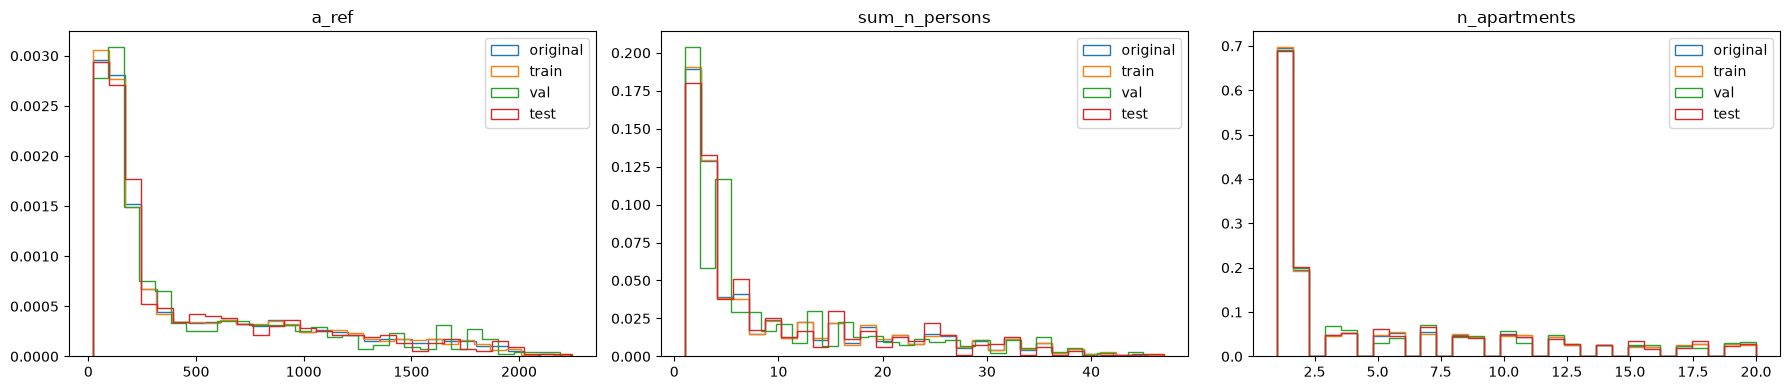

In [283]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(cont_cols), figsize=(6 * len(cont_cols), 4))
splits = {'original': buildings, 'train': buildings.loc[train_buildings],
          'val': buildings.loc[val_buildings], 'test': buildings.loc[test_buildings]}

for ax, col in zip(axes, cont_cols):
    for name, df in splits.items():
        ax.hist(df[col], bins=30, density=True, histtype='step', label=name)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [297]:
import shutil
from pathlib import Path

source_dir = Path(r"../0_DataValidation/Generation/Generation")
target_root = Path(r"../1_DataSplit/Data")

split_dirs = {
    "train": target_root/"train",
    "val": target_root/"val",
    "test": target_root/"test",
    "holdout_test": target_root/"test"/"holdout",
}

for d in split_dirs.values():
    d.mkdir(parents=True, exist_ok=True)

split_by_building = {}
for bid in train_buildings:
    split_by_building[bid] = "train"
for bid in val_buildings:
    split_by_building[bid] = "val"
for bid in test_buildings:
    split_by_building[bid] = "test"
for bid in holdout_buildings:
    split_by_building[bid] = "holdout_test"

assert manifest["building_id"].isin(split_by_building).all(), "building missing"

copied, missing = 0, []
for _, row in tqdm(manifest.iterrows(), total=len(manifest)):
    split = split_by_building[row["building_id"]]
    src = source_dir / f"{row["run_id"]}.h5"
    trgt = split_dirs[split] / f"{row["run_id"]}.h5"

    if not src.exists():
        missing.append(src)
        continue

    shutil.copy2(src, trgt)
    copied += 1

print(f"Copied: {copied}\nMissing: {len(missing)}")

  0%|          | 0/14400 [00:00<?, ?it/s]

Copied: 361
Missing: 14039
